In [1]:
from pathlib import Path
import sys


project_root = Path.cwd().resolve().parents[1]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /teamspace/studios/this_studio/SAIR-competition-modular-math


In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn

from tokenizer import DigitTokenizer

from data_streams.multiplication_data_stream import (
    MultiplicationDataStream,
)

from models.lattice_multiplication_transformer.lattice_multiplication_transformer import (
    LatticeMultiplicationLoopTransformer,
)

from models.lattice_multiplication_transformer.multiplication_training import (
    create_training_history,
    train_model,
    save_checkpoint,
    load_checkpoint,
    evaluate_model,
)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

batch_size = 64
max_seq_len = 128

length_buckets = (
    4,
    8,
    16,
    32,
    64,
    128,
)

d_model = 256
rows_per_step = 16
nhead = 4
num_encoder_layers = 2
num_decoder_layers = 2
dim_feedforward = 4 * d_model
dropout = 0.1

learning_rate = 1e-4
weight_decay = 0.1
gradient_clip_norm = 1.0

initial_max_product_value = 400
product_growth_rate = 0.0001

rehearsal_fraction = 0.2
rehearsal_max_product_value = 400
zero_sample_probability = 0.01

log_interval = 100

validation_interval = 100
validation_steps = 20
validation_lookahead_steps = 100

plot_interval = 100

checkpoint_name = "lattice_multiplication.pt"
checkpoint_interval = 50_000

use_bf16 = (
    device.type == "cuda"
    and torch.cuda.is_bf16_supported()
)

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

print("Device:", device)
print("BF16:", use_bf16)
print("Length buckets:", length_buckets)

Device: cuda
BF16: True
Length buckets: (4, 8, 16, 32, 64, 128)


In [3]:
tokenizer = DigitTokenizer()

pad_id = tokenizer.char_to_int["<pad>"]
eos_id = tokenizer.char_to_int["<eos>"]

data_stream = MultiplicationDataStream(
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_seq_len=max_seq_len,
    initial_max_product_value=initial_max_product_value,
    product_growth_rate=product_growth_rate,
    rehearsal_fraction=rehearsal_fraction,
    rehearsal_max_product_value=rehearsal_max_product_value,
    zero_sample_probability=zero_sample_probability,
    seed=42,
)

model = LatticeMultiplicationLoopTransformer(
    vocab_size=tokenizer.vocab_size,
    pad_id=pad_id,
    max_seq_len=max_seq_len,
    d_model=d_model,
    rows_per_step=rows_per_step,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

loss_function = nn.CrossEntropyLoss(
    ignore_index=pad_id,
)

training_history = create_training_history()

print(
    "Trainable parameters:",
    f"{model.count_parameters():,}",
)

print(
    "Operand sequence length:",
    data_stream.operand_seq_len,
)

print(
    "Product sequence length:",
    data_stream.product_seq_len,
)

print(
    "Initial maximum product:",
    data_stream.current_max_product_value,
)

/teamspace/studios/this_studio/SAIR-competition-modular-math/models/lattice_multiplication_transformer/lattice_multiplication_transformer.py:85: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Trainable parameters: 11,741,712
Operand sequence length: 128
Product sequence length: 257
Initial maximum product: 400.0


In [4]:
checkpoint_file_name = (
    "450000_lattice_multiplication.pt"
)

load_checkpoint(
    file_name=checkpoint_file_name,
    model=model,
    optimizer=optimizer,
    data_stream=data_stream,
    training_history=training_history,
    device=device,
)

# data_stream = MultiplicationDataStream(
#     tokenizer=tokenizer,
#     batch_size=batch_size,
#     max_seq_len=max_seq_len,
#     initial_max_product_value=14511272255630367260672,
#     product_growth_rate=0.0,
#     rehearsal_fraction=rehearsal_fraction,
#     rehearsal_max_product_value=rehearsal_max_product_value,
#     zero_sample_probability=zero_sample_probability,
#     seed=42,
# )

Checkpoint loaded from step 450,000: /teamspace/studios/this_studio/SAIR-competition-modular-math/checkpoints/450000_lattice_multiplication.pt


Training multiplication:   0%|          | 0/40000 [00:00<?, ?it/s]

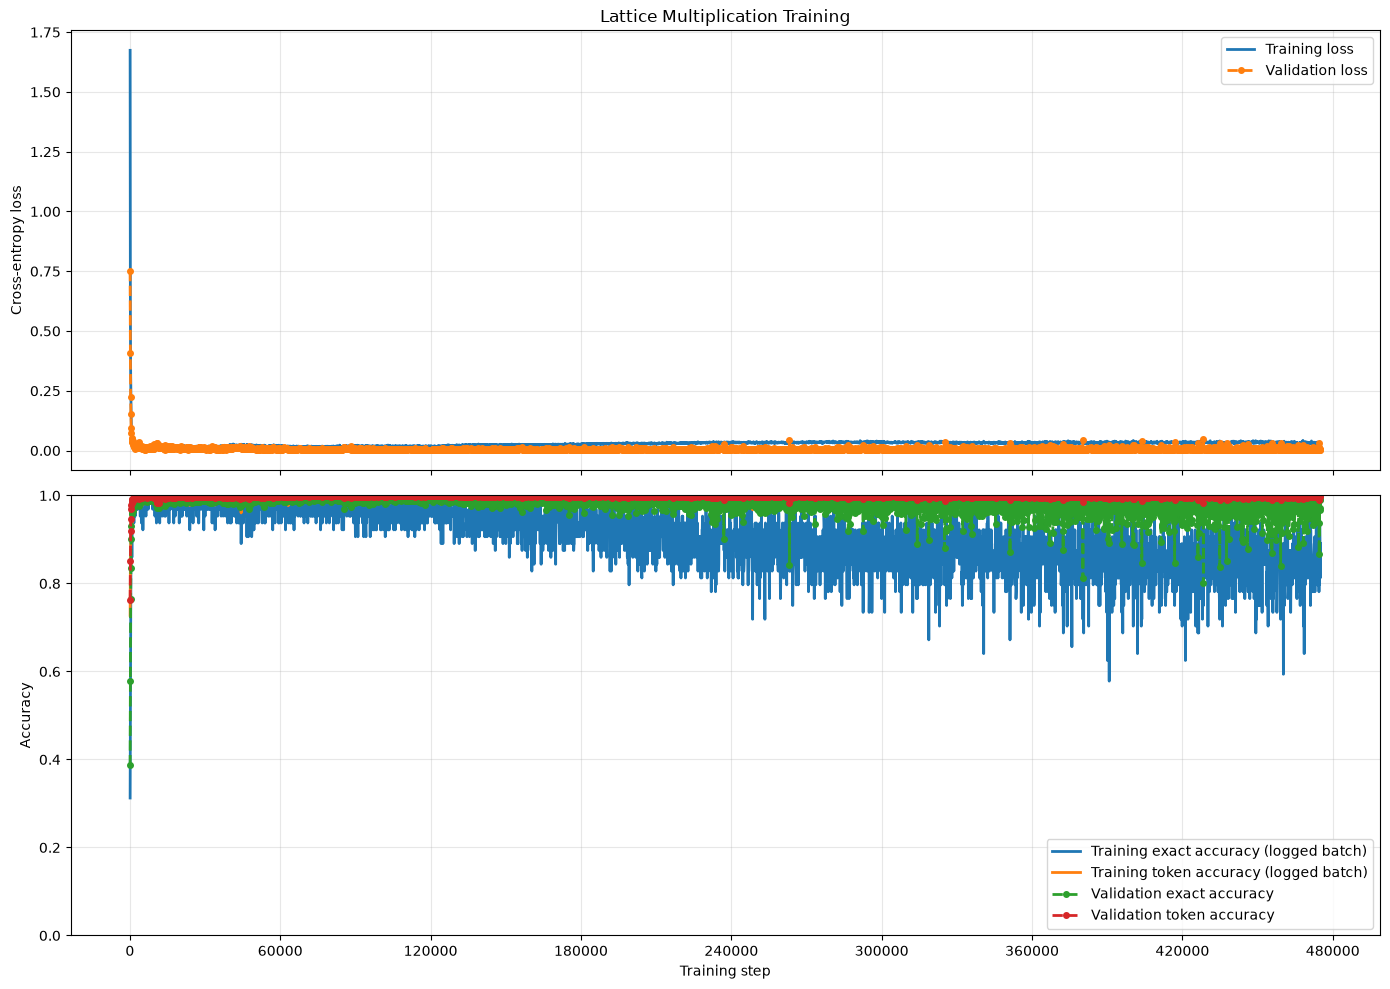

KeyboardInterrupt: 

In [7]:
train_model(
    model=model,
    data_stream=data_stream,
    optimizer=optimizer,
    loss_function=loss_function,
    tokenizer=tokenizer,
    device=device,
    training_history=training_history,
    steps=40_000,
    log_interval=log_interval,
    validation_interval=validation_interval,
    validation_steps=validation_steps,
    validation_lookahead_steps=validation_lookahead_steps,
    plot_interval=plot_interval,
    checkpoint_name=checkpoint_name,
    checkpoint_interval=checkpoint_interval,
    gradient_clip_norm=gradient_clip_norm,
    length_buckets=length_buckets,
    use_bf16=use_bf16,
)

In [ ]:
# checkpoint_file_name = (
#     "my_lattice_multiplication_checkpoint.pt"
# )

# save_checkpoint(
#     file_name=checkpoint_file_name,
#     model=model,
#     optimizer=optimizer,
#     data_stream=data_stream,
#     training_history=training_history,
# )

In [8]:
evaluate_model(
    model=model,
    data_stream=data_stream,
    tokenizer=tokenizer,
    device=device,
    max_product_value=100_000,
    number_of_samples=100,
    length_buckets=length_buckets,
    use_bf16=use_bf16,
)

Evaluating multiplication:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy: 0.070000 (7/100)

Wrong predictions:

36 × 48 = 1728
Prediction: 1528

140 × 87 = 12180
Prediction: 8180

102 × 666 = 67932
Prediction: 32093293529392932

151 × 143 = 21593
Prediction: 754075493

173 × 56 = 9688
Prediction: 8588

89 × 271 = 24119
Prediction: 2119

776 × 64 = 49664
Prediction: 75767564

296 × 186 = 55056
Prediction: 25660471056

117 × 297 = 34749
Prediction: 83318332849

143 × 49 = 7007
Prediction: 0210007
